In [1]:
import pandas as pd

In [2]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [8]:
df=pd.read_csv(r"D:\DATA ANALYSIS\E-commerce Funnel & RFM\Data\cleaned\online_retail_clean.csv",parse_dates=['InvoiceDate'])
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
776619,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
776620,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
776621,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
776622,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [9]:
print("Shape: ",df.shape)

Shape:  (776624, 9)


In [10]:
print("Date Range: ",df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

Date Range:  2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [11]:
print("Unique customers:",df['Customer ID'].nunique())

Unique customers: 5861


In [12]:
#Set the Snapshot Date

In [13]:
snapshot_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)
print(f"Last transaction:  {df['InvoiceDate'].max()}")
print(f"Snapshot date:     {snapshot_date}")

Last transaction:  2011-12-09 12:50:00
Snapshot date:     2011-12-10 12:50:00


In [14]:
#Calculate R, F, M per Customer

In [15]:
rfm=df.groupby('Customer ID').agg({'InvoiceDate': lambda x:(snapshot_date - x.max()).days,'Invoice': 'nunique','TotalPrice':'sum'}).reset_index()

In [16]:
# Rename columns for clarity
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [17]:
print("RFM table shape:", rfm.shape)
print("\nFirst 5 rows:")
rfm.head()

print("\nRFM descriptive stats:")
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

RFM table shape: (5861, 4)

First 5 rows:

RFM descriptive stats:


,Recency,Frequency,Monetary
count,5861.00,5861.00,5861.00
mean,200.94,6.25,2913.00
std,209.20,12.77,14300.54
min,1.00,1.00,2.95
25%,26.00,1.00,338.13
50%,96.00,3.00,854.99
75%,379.00,7.00,2237.12
max,739.00,376.00,580987.04


In [24]:
#Quick Look at Distributions

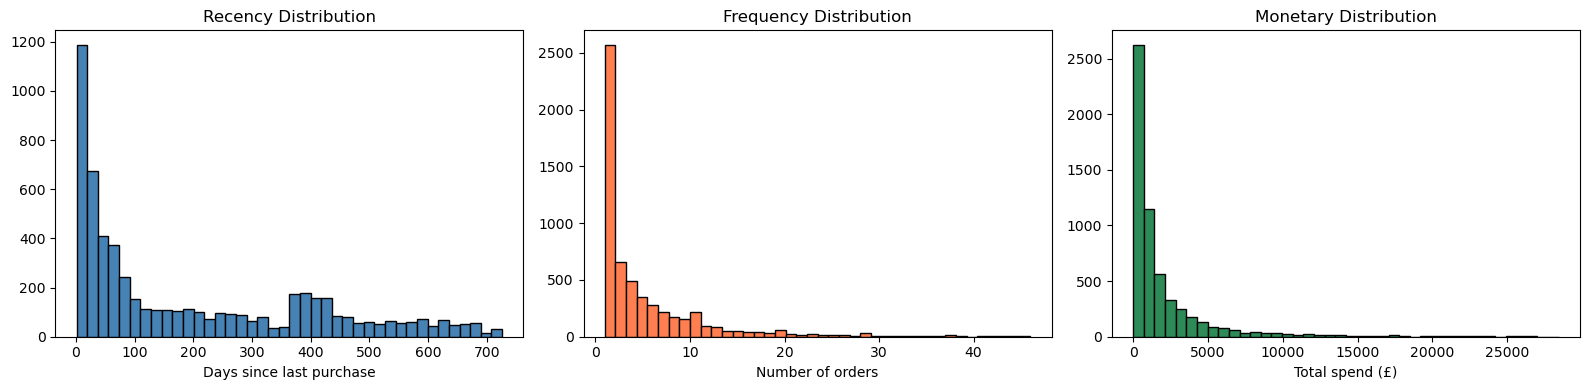

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(rfm['Recency'][rfm['Recency'] <= rfm['Recency'].quantile(0.99)], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last purchase')

axes[1].hist(rfm['Frequency'][rfm['Frequency'] <= rfm['Frequency'].quantile(0.99)], bins=40, color='coral', edgecolor='black')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of orders')

axes[2].hist(rfm['Monetary'][rfm['Monetary'] <= rfm['Monetary'].quantile(0.99)], bins=40, color='seagreen', edgecolor='black')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total spend (£)')

plt.tight_layout()
plt.show()

In [28]:
#Score R, F, M Using Quartiles

In [29]:
# Recency: LOWER is better → reversed scoring
# Frequency and Monetary: HIGHER is better → normal scoring

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

print("Scoring complete. First 10 rows:")
rfm.head(10)

Scoring complete. First 10 rows:


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346,326,12,77556.46,2,4,4
1,12347,2,8,4921.53,4,4,4
2,12348,75,5,1658.40,3,3,3
3,12349,19,3,3678.69,4,2,4
4,12350,310,1,294.40,2,1,1
5,12351,375,1,300.93,2,1,1
6,12352,36,9,1729.54,3,4,3
7,12353,204,2,406.76,2,2,2
8,12354,232,1,1079.40,2,1,3
9,12355,214,2,947.61,2,2,3


In [30]:
print(rfm['R_Score'].value_counts().sort_index())
print(rfm['F_Score'].value_counts().sort_index())
print(rfm['M_Score'].value_counts().sort_index())

R_Score
1    1462
2    1452
3    1437
4    1510
Name: count, dtype: int64
F_Score
1    1466
2    1465
3    1465
4    1465
Name: count, dtype: int64
M_Score
1    1466
2    1465
3    1465
4    1465
Name: count, dtype: int64


In [31]:
#Combine Scores and Assign Segments

In [32]:
# Combine scores into a single string like "444" for easy reference
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) +
                    rfm['F_Score'].astype(str) +
                    rfm['M_Score'].astype(str))

In [33]:
# Assign segment based on scores
def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("Segment counts:")
print(rfm['Segment'].value_counts())

Segment counts:
Segment
Lost                  1764
Loyal Customers       1157
Others                 875
Champions              659
At Risk                639
Potential Loyalist     426
New Customers          341
Name: count, dtype: int64


In [34]:
#Segment Distribution — Customer Count

C:\Users\Prince\AppData\Local\Temp\ipykernel_24496\645617116.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='viridis')


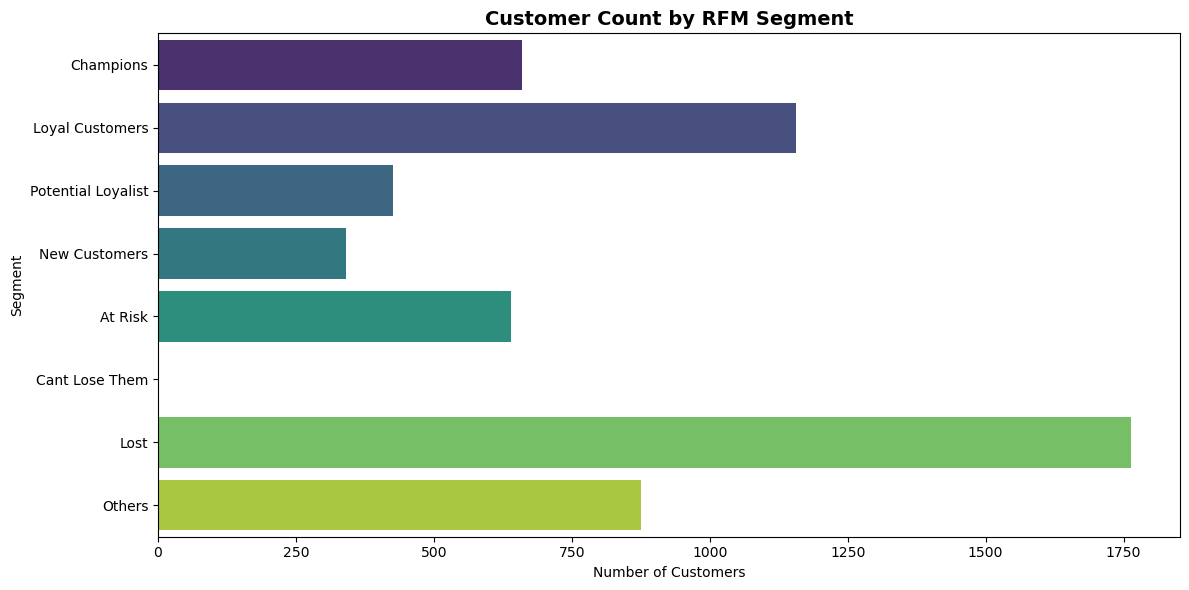


Customer % by segment:
Segment
Champions             11.24
Loyal Customers       19.74
Potential Loyalist     7.27
New Customers          5.82
At Risk               10.90
Cant Lose Them         0.00
Lost                  30.10
Others                14.93
Name: count, dtype: float64


In [36]:
segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalist',
                 'New Customers', 'At Risk', 'Cant Lose Them',
                 'Lost', 'Others']

segment_counts = rfm['Segment'].value_counts().reindex(segment_order).fillna(0)

plt.figure(figsize=(12, 6))
sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='viridis')
plt.title('Customer Count by RFM Segment', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.show()

# Percentages
print("\nCustomer % by segment:")
print((segment_counts / segment_counts.sum() * 100).round(2))

In [37]:
#Revenue by Segment

C:\Users\Prince\AppData\Local\Temp\ipykernel_24496\2738642625.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_revenue.values, y=segment_revenue.index, palette='rocket')


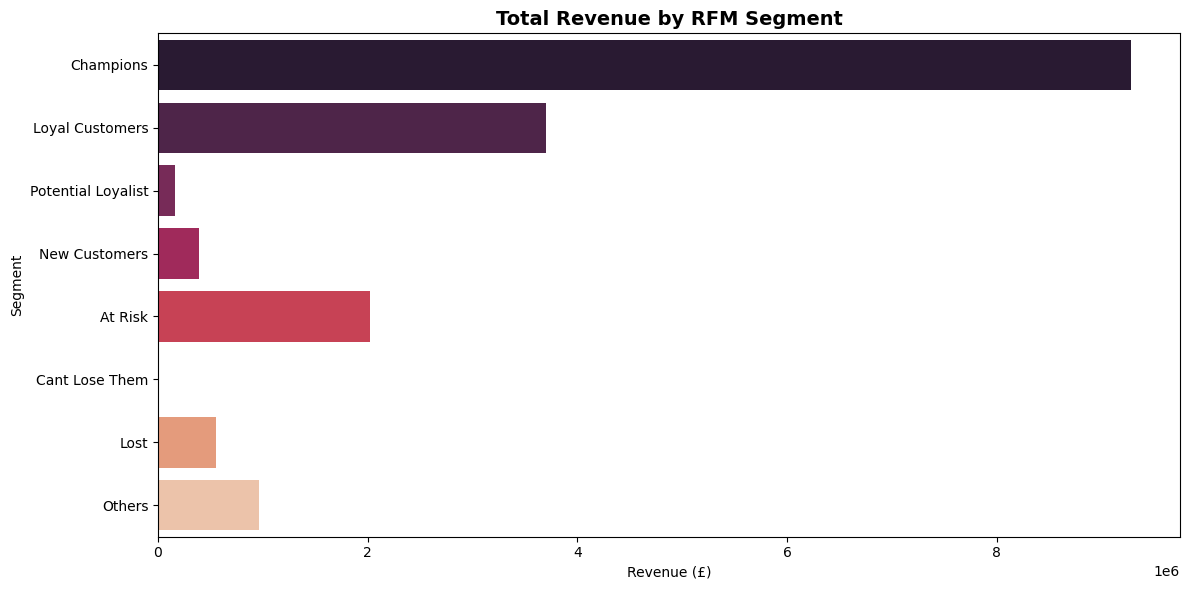

In [38]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().reindex(segment_order).fillna(0)

plt.figure(figsize=(12, 6))
sns.barplot(x=segment_revenue.values, y=segment_revenue.index, palette='rocket')
plt.title('Total Revenue by RFM Segment', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.show()

In [39]:
# Percentages
print("\nRevenue % by segment:")
print((segment_revenue / segment_revenue.sum() * 100).round(2))


Revenue % by segment:
Segment
Champions             54.37
Loyal Customers       21.68
Potential Loyalist     0.95
New Customers          2.26
At Risk               11.86
Cant Lose Them         0.00
Lost                   3.25
Others                 5.62
Name: Monetary, dtype: float64


In [40]:
#Compare Customer % vs Revenue %

In [41]:
comparison = pd.DataFrame({
    'Customer_Pct': segment_counts / segment_counts.sum() * 100,
    'Revenue_Pct': segment_revenue / segment_revenue.sum() * 100
}).round(2)

comparison['Revenue_vs_Customer'] = (comparison['Revenue_Pct'] - comparison['Customer_Pct']).round(2)

print("\nCustomer % vs Revenue % by Segment:")
print(comparison)


Customer % vs Revenue % by Segment:
                    Customer_Pct  Revenue_Pct  Revenue_vs_Customer
Segment                                                           
Champions                  11.24        54.37                43.13
Loyal Customers            19.74        21.68                 1.94
Potential Loyalist          7.27         0.95                -6.32
New Customers               5.82         2.26                -3.56
At Risk                    10.90        11.86                 0.96
Cant Lose Them              0.00         0.00                 0.00
Lost                       30.10         3.25               -26.85
Others                     14.93         5.62                -9.31


In [42]:
#Average RFM per Segment

In [43]:
segment_avg = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).reindex(segment_order).round(2)

segment_avg.columns = ['Avg_Recency (days)', 'Avg_Frequency (orders)',
                       'Avg_Monetary (£)', 'Customer_Count']

print("\nAverage RFM per Segment:")
print(segment_avg)


Average RFM per Segment:
                    Avg_Recency (days)  Avg_Frequency (orders)  \
Segment                                                          
Champions                        10.41                   24.27   
Loyal Customers                  40.15                    8.12   
Potential Loyalist               56.19                    1.52   
New Customers                    13.75                    1.90   
At Risk                         269.27                    7.35   
Cant Lose Them                     NaN                     NaN   
Lost                            418.83                    1.38   
Others                          211.28                    3.22   

                    Avg_Monetary (£)  Customer_Count  
Segment                                               
Champions                   14086.22           659.0  
Loyal Customers              3198.79          1157.0  
Potential Loyalist            381.94           426.0  
New Customers                1133.99  

In [44]:
#Save RFM Output

In [45]:
rfm.to_csv("D:/DATA ANALYSIS/E-commerce Funnel & RFM/Data/cleaned/rfm_segments.csv", index=False)

print("Saved: rfm_segments.csv")
print("Shape:", rfm.shape)
print("Columns:", rfm.columns.tolist())

Saved: rfm_segments.csv
Shape: (5861, 9)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']


In [46]:
#Final Summary

In [47]:
print("=" * 60)
print("RFM SEGMENTATION SUMMARY")
print("=" * 60)

print(f"\nTotal customers segmented: {len(rfm):,}")

print("\nTop 3 segments by customer count:")
top3_count = segment_counts.head(3)
for seg, cnt in top3_count.items():
    print(f"  - {seg}: {cnt:,} ({cnt/len(rfm)*100:.1f}%)")

print("\nTop 3 segments by revenue:")
top3_rev = segment_revenue.sort_values(ascending=False).head(3)
for seg, rev in top3_rev.items():
    print(f"  - {seg}: £{rev:,.2f} ({rev/segment_revenue.sum()*100:.1f}%)")

print("\nKey Insight:")
champ_rev_pct = segment_revenue.get('Champions', 0) / segment_revenue.sum() * 100
champ_cust_pct = segment_counts.get('Champions', 0) / segment_counts.sum() * 100
print(f"  Champions: {champ_cust_pct:.1f}% of customers but {champ_rev_pct:.1f}% of revenue")

print("=" * 60)
print("\nNext step: MySQL - load data + run funnel/business queries")

RFM SEGMENTATION SUMMARY

Total customers segmented: 5,861

Top 3 segments by customer count:
  - Champions: 659.0 (11.2%)
  - Loyal Customers: 1,157.0 (19.7%)
  - Potential Loyalist: 426.0 (7.3%)

Top 3 segments by revenue:
  - Champions: £9,282,816.37 (54.4%)
  - Loyal Customers: £3,701,002.38 (21.7%)
  - At Risk: £2,024,835.44 (11.9%)

Key Insight:
  Champions: 11.2% of customers but 54.4% of revenue

Next step: MySQL - load data + run funnel/business queries
